In [1]:
!pip install opendatasets --quiet
import opendatasets as od
od.download("https://www.kaggle.com/datasets/andrewmvd/animal-faces")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: RISHIT MAHINDRU
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/andrewmvd/animal-faces


100%|██████████| 696M/696M [00:06<00:00, 109MB/s]


In [2]:
import torch # Main PyTorch Library
import random
from torch import nn # Used for creating the layers and loss function
from torch.optim import Adam # Adam Optimizer
import torchvision.transforms as transforms # Transform function used to modify and preprocess all the images
from torch.utils.data import Dataset, DataLoader # Dataset class and DataLoader for creating the objects
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder # Label Encoder to encode the classes from strings to numbers
import matplotlib.pyplot as plt # Used for visualizing the images and plotting the training progress
from PIL import Image # Used to read the images from the directory
import pandas as pd # Used to read/create dataframes (csv) and process tabular data
import numpy as np # preprocessing and numerical/mathematical operations
import seaborn as sns
import os # Used to read the images path from the directory

device = "cuda" if torch.cuda.is_available() else "cpu" # detect the GPU if any, if not use CPU, change cuda to mps if you have a mac
print("Device available: ", device)
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

Device available:  cuda


In [3]:
image_path = [] # Empty array where we will fill the paths of the images
labels = [] # Empty array where we will fill the labes of the images

for i in os.listdir("/content/animal-faces/afhq/"): # Looping through the first directory which has the train and val images
  for label in os.listdir(f"/content/animal-faces/afhq/{i}"): # Looping through the first directory which has the labels folders
    for image in os.listdir(f"/content/animal-faces/afhq/{i}/{label}"): # Looping through all the images of this label
      labels.append(label) # Append/Put this label in the list
      image_path.append(f"/content/animal-faces/afhq/{i}/{label}/{image}") # Append/Put this image path in the list to read it later

data_df = pd.DataFrame(zip(image_path, labels), columns = ['image_paths', 'labels']) # Create a dataframe contains the images paths and the labels
data_df.head() # Visualizing the first 5 rows

,image_paths,labels
0,/content/animal-faces/afhq/train/wild/flickr_w...,wild
1,/content/animal-faces/afhq/train/wild/pixabay_...,wild
2,/content/animal-faces/afhq/train/wild/flickr_w...,wild
3,/content/animal-faces/afhq/train/wild/flickr_w...,wild
4,/content/animal-faces/afhq/train/wild/flickr_w...,wild


In [4]:
train, temp = train_test_split(
    data_df,
    test_size=0.30,
    stratify=data_df["labels"],
    random_state=42
)

val, test = train_test_split(
    temp,
    test_size=0.50,
    stratify=temp["labels"],
    random_state=42
)


In [5]:
label_encoder = LabelEncoder() # Encode the string classes to numeric
label_encoder.fit(data_df['labels']) # Fit the label encoder on our own data

train_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])


In [6]:
class CustomImageDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform
        self.labels = torch.tensor(label_encoder.transform(dataframe['labels'])).to(device)

    def __len__(self):
        return self.dataframe.shape[0]

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx, 0]
        label = self.labels[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
          image = self.transform(image)

        return image, label

In [7]:
train_dataset = CustomImageDataset(
    dataframe=train,
    transform=train_transform
)

val_dataset = CustomImageDataset(
    dataframe=val,
    transform=test_transform
)

test_dataset = CustomImageDataset(
    dataframe=test,
    transform=test_transform
)


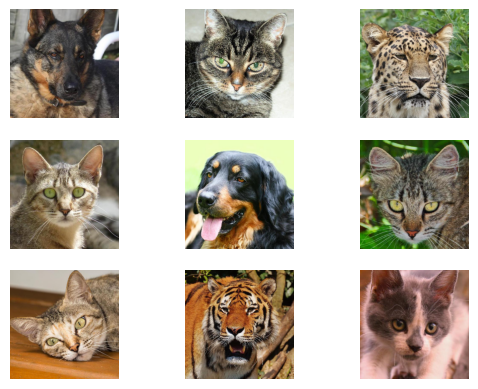

In [8]:
n_rows = 3
n_cols = 3
f, axarr = plt.subplots(n_rows, n_cols)
for row in range(n_rows):
    for col in range(n_cols):
      image = Image.open(data_df.sample(n = 1)['image_paths'].iloc[0]).convert("RGB")
      axarr[row, col].imshow(image)
      axarr[row, col].axis('off')

plt.show()

In [9]:
LR = 1e-4
BATCH_SIZE = 16
EPOCHS = 10
PATIENCE = 3

In [10]:
train_loader = DataLoader(train_dataset,
                          batch_size=BATCH_SIZE,
                          shuffle=True)

val_loader = DataLoader(val_dataset,
                        batch_size=BATCH_SIZE,
                        shuffle=False)

test_loader = DataLoader(test_dataset,
                         batch_size=BATCH_SIZE,
                         shuffle=False)

In [11]:
class Net(nn.Module):
    def __init__(self):
      super().__init__()

      self.conv1 = nn.Conv2d(3, 32, kernel_size = 3, padding = 1) # First Convolution layer
      self.conv2 = nn.Conv2d(32, 64, kernel_size = 3, padding = 1) # Second Convolution layer
      self.conv3 = nn.Conv2d(64, 128, kernel_size = 3, padding = 1) # Third Convolution layer
      self.pooling = nn.MaxPool2d(2,2) # The pooling layer, we will be using the same layer after each conv2d.
      self.relu = nn.ReLU() # ReLU Activation function

      self.flatten = nn.Flatten() # Flatten and vectorize the output feature maps that somes from the final convolution layer.
      self.linear = nn.Linear((128 * 16 * 16), 128) # Traditional Dense (Linear)
      self.output = nn.Linear(128, len(data_df['labels'].unique())) # Output Linear Layer


    def forward(self, x):
      x = self.conv1(x) # -> Outputs: (32, 128, 128)
      x = self.pooling(x)# -> Outputs: (32, 64, 64)
      x = self.relu(x)
      x = self.conv2(x) # -> Outputs: (64, 64, 64)
      x = self.pooling(x) # -> Outputs: (64, 32, 32)
      x = self.relu(x)
      x = self.conv3(x) # -> Outputs: (128, 32, 32)
      x = self.pooling(x) # -> Outputs: (128, 16, 16)
      x = self.relu(x)
      x = self.flatten(x)
      x = self.linear(x)
      x = self.output(x)

      return x

model = Net().to(device) # Create an instance of the model and move it to the GPU Device


In [12]:
from torchsummary import summary
summary(model, input_size = (3, 128, 128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
         MaxPool2d-2           [-1, 32, 64, 64]               0
              ReLU-3           [-1, 32, 64, 64]               0
            Conv2d-4           [-1, 64, 64, 64]          18,496
         MaxPool2d-5           [-1, 64, 32, 32]               0
              ReLU-6           [-1, 64, 32, 32]               0
            Conv2d-7          [-1, 128, 32, 32]          73,856
         MaxPool2d-8          [-1, 128, 16, 16]               0
              ReLU-9          [-1, 128, 16, 16]               0
          Flatten-10                [-1, 32768]               0
           Linear-11                  [-1, 128]       4,194,432
           Linear-12                    [-1, 3]             387
Total params: 4,288,067
Trainable params: 4,288,067
Non-trainable params: 0
---------------------------

In [13]:
criterion = nn.CrossEntropyLoss() # Cross Entropy Loss
optimizer = Adam(model.parameters(), lr=LR) # Adam optimizer
best_val_loss = float("inf")
counter = 0

In [16]:
total_loss_train_plot = []
total_loss_validation_plot = []
total_acc_train_plot = []
total_acc_validation_plot = []


for epoch in range(EPOCHS):
  total_acc_train = 0
  total_loss_train = 0
  total_loss_val = 0
  total_acc_val = 0
  model.train()

  for inputs, labels in train_loader:
    inputs = inputs.to(device)
    labels = labels.to(device)
    optimizer.zero_grad()
    outputs = model(inputs)
    train_loss = criterion(outputs, labels)
    total_loss_train += train_loss.item()
    train_loss.backward()

    train_acc = (torch.argmax(outputs, axis = 1) == labels).sum().item()
    total_acc_train += train_acc
    optimizer.step()

  model.eval()

  with torch.no_grad():
    for inputs, labels in val_loader:
      inputs = inputs.to(device)
      labels = labels.to(device)
      outputs = model(inputs)
      val_loss = criterion(outputs, labels)
      total_loss_val += val_loss.item()

      val_acc = (torch.argmax(outputs, axis = 1) == labels).sum().item()
      total_acc_val += val_acc

  avg_train_loss = total_loss_train / len(train_loader)
  avg_val_loss = total_loss_val / len(val_loader)

  total_loss_train_plot.append(round(avg_train_loss,4))
  total_loss_validation_plot.append(round(avg_val_loss,4))
  total_acc_train_plot.append(round(total_acc_train/(train_dataset.__len__())*100, 4))
  total_acc_validation_plot.append(round(total_acc_val/(val_dataset.__len__())*100, 4))
  print(f'''
Epoch {epoch+1}

Train Accuracy: {round(total_acc_train/len(train_dataset)*100,2)}%

Validation Accuracy: {round(total_acc_val/len(val_dataset)*100,2)}%

Train Loss: {round(avg_train_loss,4)}

Validation Loss: {round(avg_val_loss,4)}
''')


  print("="*25)
  avg_val_loss = total_loss_val / len(val_loader)

  if avg_val_loss < best_val_loss:
      best_val_loss = avg_val_loss
      counter = 0
      torch.save(model.state_dict(), "best_model.pth")
  else:
      counter += 1

  if counter >= PATIENCE:
      print("Early stopping...")
      break


Epoch 1

Train Accuracy: 96.4%

Validation Accuracy: 96.73%

Train Loss: 0.1026

Validation Loss: 0.0996


Epoch 2

Train Accuracy: 96.68%

Validation Accuracy: 96.86%

Train Loss: 0.0917

Validation Loss: 0.0958


Epoch 3

Train Accuracy: 97.21%

Validation Accuracy: 96.44%

Train Loss: 0.0777

Validation Loss: 0.0973


Epoch 4

Train Accuracy: 97.25%

Validation Accuracy: 97.27%

Train Loss: 0.0728

Validation Loss: 0.0842


Epoch 5

Train Accuracy: 97.69%

Validation Accuracy: 97.44%

Train Loss: 0.0624

Validation Loss: 0.0797


Epoch 6

Train Accuracy: 98.1%

Validation Accuracy: 97.02%

Train Loss: 0.0528

Validation Loss: 0.0882


Epoch 7

Train Accuracy: 98.41%

Validation Accuracy: 97.31%

Train Loss: 0.0472

Validation Loss: 0.0845


Epoch 8

Train Accuracy: 98.32%

Validation Accuracy: 97.27%

Train Loss: 0.0487

Validation Loss: 0.0903

Early stopping...


In [17]:
model.load_state_dict(torch.load("best_model.pth"))
model.to(device)
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
  total_loss_test = 0
  total_acc_test = 0
  for inputs, labels in test_loader:
    inputs = inputs.to(device)
    labels = labels.to(device)
    predictions = model(inputs)
    all_preds.extend(torch.argmax(predictions, dim=1).cpu().numpy())
    all_labels.extend(labels.cpu().numpy())

    acc = (torch.argmax(predictions, axis = 1) == labels).sum().item()
    total_acc_test += acc
    test_loss = criterion(predictions, labels)
    total_loss_test += test_loss.item()

avg_test_loss = total_loss_test / len(test_loader)

test_accuracy = (total_acc_test / len(test_dataset)) * 100

print(f"""
Test Accuracy : {test_accuracy:.2f}%

Test Loss     : {avg_test_loss:.4f}
""")


Test Accuracy : 97.52%

Test Loss     : 0.0699



In [18]:
print(classification_report(
    all_labels,
    all_preds,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

         cat       0.99      0.98      0.99       848
         dog       0.98      0.96      0.97       786
        wild       0.95      0.98      0.97       786

    accuracy                           0.98      2420
   macro avg       0.98      0.98      0.97      2420
weighted avg       0.98      0.98      0.98      2420



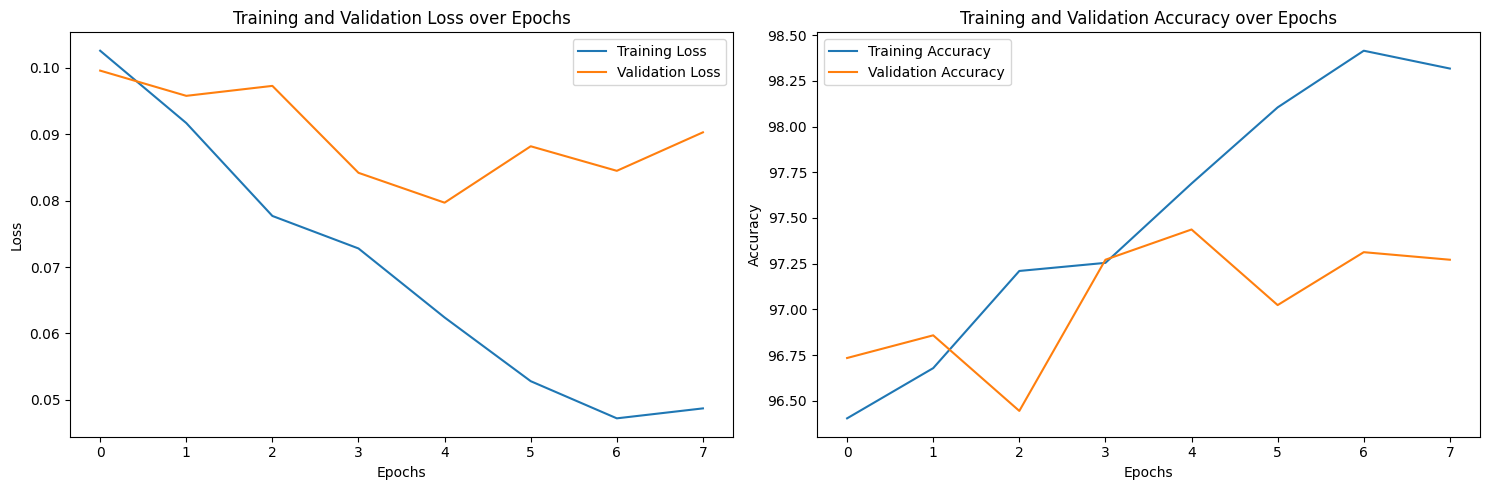

In [19]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

axs[0].plot(total_loss_train_plot, label='Training Loss')
axs[0].plot(total_loss_validation_plot, label='Validation Loss')
axs[0].set_title('Training and Validation Loss over Epochs')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].legend()

axs[1].plot(total_acc_train_plot, label='Training Accuracy')
axs[1].plot(total_acc_validation_plot, label='Validation Accuracy')
axs[1].set_title('Training and Validation Accuracy over Epochs')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].legend()

plt.tight_layout()

plt.show()

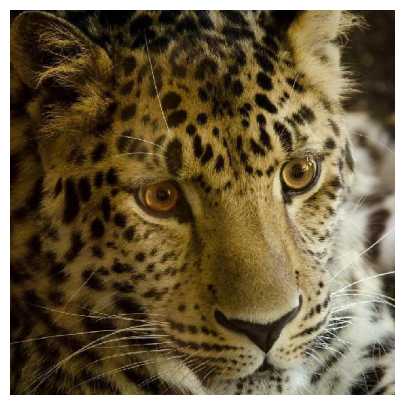

Prediction: wild


In [23]:
# 1- read image
# 2- Transform using transform object
# 3- predict through the model
# 4- inverse transform by label encoder

def predict_image(image_path):

    model.eval()

    image = Image.open(image_path).convert("RGB")

    image = test_transform(image)

    image = image.to(device)

    with torch.no_grad():

        output = model(image.unsqueeze(0))

        prediction = torch.argmax(output, dim=1).item()

    return label_encoder.inverse_transform([prediction])[0]

# Image path
image_path = "/content/animal-faces/afhq/val/wild/pixabay_wild_000965.jpg"

# Display image
image = Image.open(image_path)

plt.figure(figsize=(5,5))
plt.imshow(image)
plt.axis("off")
plt.show()

# Prediction
prediction = predict_image(image_path)

print(f"Prediction: {prediction}")


In [20]:
import joblib

joblib.dump(label_encoder, "label_encoder.pkl")

['label_encoder.pkl']